# RL Feature Exploration

## RL Concept

- State: current feature subset
- Action: add/remove feature
- Reward: improvement in ROC-AUC


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, random
from pathlib import Path
from collections import defaultdict

current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader
from src.features.feature_engineering import FeatureEngineer

loader = DataLoader()
data   = loader.load_all('train')

fe      = FeatureEngineer()
df_feat = fe.fit_transform(data['transactions'], data['customers'], data['terminals'])

drop_cols = ['TX_FRAUD', 'TRANSACTION_ID', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_DATETIME']
X = df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns], errors='ignore')
X = X.select_dtypes(include=np.number).fillna(0)
y = df_feat['TX_FRAUD']

print(f"Feature matrix : {X.shape}")
print(f"Class balance  : {y.mean():.3%} fraud")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
🔧 Feature Engineering Pipeline Starting...
   Input: 291,231 transactions
   ✓ Merged tables: (291231, 15)
   ✓ Temporal features (14)
   ✓ Geographic features (2)
   ✓ Amount deviation features (6)
   ✓ Terminal risk features (5) - YOUR TOP FEATURES!
   ✓ Customer behavioral features (3)
   ✓ Advanced contextual features (7)
   ✓ Interaction features (6)

✅ Complete: 57 features created!
Feature matrix : (291231, 51)
Class balance  : 2.260% fraud


/Users/kgothatso/Downloads/credit_fraud_ml/src/features/feature_engineering.py:195: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['terminal_fraud_rate'].fillna(self.overall_fraud_rate, inplace=True)
/Users/kgothatso/Downloads/credit_fraud_ml/src/features/feature_engineering.py:196: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

features   = list(X.columns)
n_features = len(features)
print(f"Train : {X_train.shape}, Val : {X_val.shape}")
print(f"Features available : {n_features}")

def evaluate_subset(selected_feats):
    """Fast ROC-AUC evaluation using a shallow LightGBM."""
    if len(selected_feats) == 0:
        return 0.5
    model = lgb.LGBMClassifier(
        n_estimators=80, learning_rate=0.1, max_depth=4, num_leaves=15,
        class_weight='balanced', random_state=42, verbosity=-1
    )
    model.fit(X_train[selected_feats], y_train)
    proba = model.predict_proba(X_val[selected_feats])[:, 1]
    return roc_auc_score(y_val, proba)

Train : (232984, 51), Val : (58247, 51)
Features available : 51


In [3]:
class FeatureSelectionEnv:
    """
    RL environment for feature selection.
      State  : frozenset of currently selected feature names
      Action : ('add', feat) or ('remove', feat)
      Reward : ROC-AUC minus 0.5 (so random baseline = 0 reward)
    """
    def __init__(self, all_features, evaluator_fn, baseline=0.5):
        self.all_features = all_features
        self.evaluator    = evaluator_fn
        self.baseline     = baseline
        self.selected     = set()

    def reset(self):
        k = random.randint(1, min(5, len(self.all_features)))
        self.selected = set(random.sample(self.all_features, k))
        return frozenset(self.selected)

    def step(self, action):
        op, feat = action
        if op == 'add' and feat not in self.selected:
            self.selected.add(feat)
        elif op == 'remove' and len(self.selected) > 1:
            self.selected.discard(feat)
        auc    = self.evaluator(list(self.selected))
        reward = auc - self.baseline
        return frozenset(self.selected), reward, auc

    def get_actions(self):
        actions = []
        for f in self.all_features:
            if f not in self.selected:
                actions.append(('add', f))
            elif len(self.selected) > 1:
                actions.append(('remove', f))
        return actions

In [4]:
class EpsilonGreedyAgent:
    """
    Epsilon-greedy Q-learning agent.
    Q is keyed by (state, op, feature) — only visited (state, action) pairs are stored.
    """
    def __init__(self, epsilon=0.5, alpha=0.2, gamma=0.9):
        self.epsilon = epsilon
        self.alpha   = alpha
        self.gamma   = gamma
        self.Q       = defaultdict(float)

    def get_action(self, state, actions):
        if random.random() < self.epsilon:
            return random.choice(actions)
        q_vals = {a: self.Q[(state, a[0], a[1])] for a in actions}
        return max(q_vals, key=q_vals.get)

    def update(self, state, action, reward, next_state, next_actions):
        sa      = (state, action[0], action[1])
        next_q  = max(
            (self.Q[(next_state, a[0], a[1])] for a in next_actions), default=0.0
        )
        self.Q[sa] += self.alpha * (reward + self.gamma * next_q - self.Q[sa])

    def decay_epsilon(self, rate=0.97, floor=0.05):
        self.epsilon = max(floor, self.epsilon * rate)

In [5]:
# ── 3. Training Loop ─────────────────────────────────────────────────────────
N_EPISODES        = 40
STEPS_PER_EPISODE = 12

env   = FeatureSelectionEnv(features, evaluate_subset)
agent = EpsilonGreedyAgent(epsilon=0.5, alpha=0.2, gamma=0.9)

episode_aucs    = []
episode_rewards = []
best_auc        = 0.0
best_features   = []
feature_visits  = defaultdict(int)

print(f"Training RL agent: {N_EPISODES} episodes × {STEPS_PER_EPISODE} steps")
print("-" * 58)

for ep in range(N_EPISODES):
    state     = env.reset()
    ep_reward = 0.0
    ep_auc    = 0.5

    for step in range(STEPS_PER_EPISODE):
        actions = env.get_actions()
        if not actions:
            break
        action                   = agent.get_action(state, actions)
        next_state, reward, auc  = env.step(action)
        next_actions             = env.get_actions()

        agent.update(state, action, reward, next_state, next_actions)
        state      = next_state
        ep_reward += reward
        ep_auc     = auc

        for f in env.selected:
            feature_visits[f] += 1

        if auc > best_auc:
            best_auc      = auc
            best_features = list(env.selected)

    agent.decay_epsilon()
    episode_aucs.append(ep_auc)
    episode_rewards.append(ep_reward)

    if (ep + 1) % 8 == 0:
        print(f"  Ep {ep+1:2d}/{N_EPISODES}  AUC {ep_auc:.4f}  "
              f"Best {best_auc:.4f}  ε={agent.epsilon:.3f}  n_feats={len(env.selected)}")

print(f"\nBest ROC-AUC : {best_auc:.4f}  using {len(best_features)} features")

Training RL agent: 40 episodes × 12 steps
----------------------------------------------------------
  Ep  8/40  AUC 0.7249  Best 0.8869  ε=0.392  n_feats=7
  Ep 16/40  AUC 0.8750  Best 0.8880  ε=0.307  n_feats=7
  Ep 24/40  AUC 0.6692  Best 0.8886  ε=0.241  n_feats=6
  Ep 32/40  AUC 0.6482  Best 0.8929  ε=0.189  n_feats=6
  Ep 40/40  AUC 0.6165  Best 0.8929  ε=0.148  n_feats=3

Best ROC-AUC : 0.8929  using 8 features


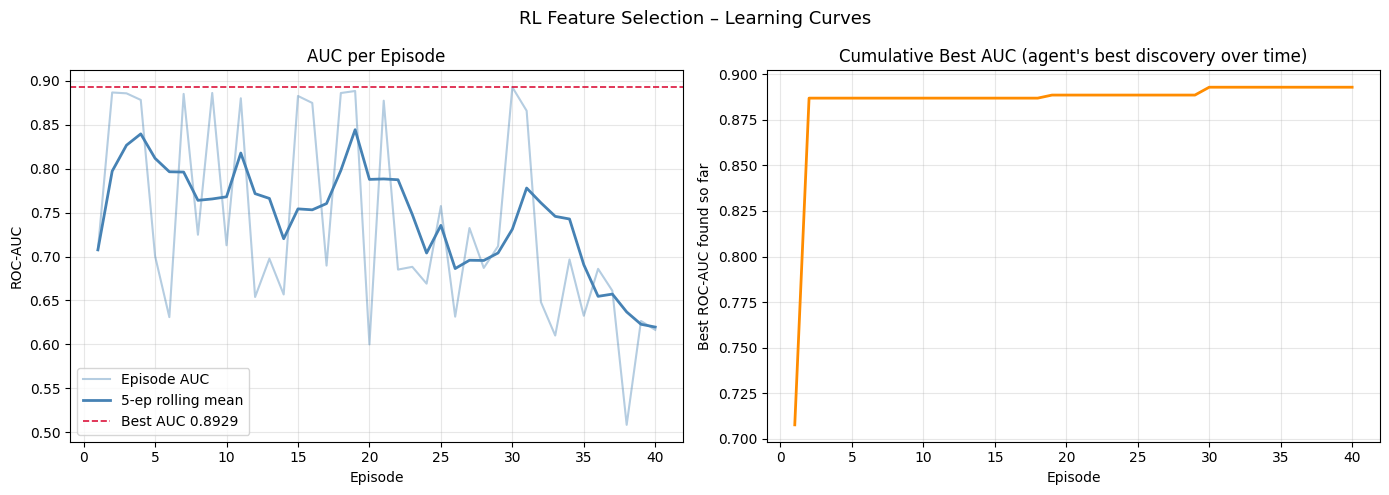

In [6]:
# ── 4. Learning Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rolling = pd.Series(episode_aucs).rolling(5, min_periods=1).mean()
axes[0].plot(range(1, N_EPISODES+1), episode_aucs,
             alpha=0.4, color='steelblue', label='Episode AUC')
axes[0].plot(range(1, N_EPISODES+1), rolling,
             color='steelblue', linewidth=2.0, label='5-ep rolling mean')
axes[0].axhline(best_auc, color='crimson', linestyle='--',
                linewidth=1.2, label=f'Best AUC {best_auc:.4f}')
axes[0].set_title('AUC per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cummax = pd.Series(episode_aucs).cummax()
axes[1].plot(range(1, N_EPISODES+1), cummax, color='darkorange', linewidth=2)
axes[1].set_title('Cumulative Best AUC (agent\'s best discovery over time)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Best ROC-AUC found so far')
axes[1].grid(True, alpha=0.3)

plt.suptitle('RL Feature Selection – Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

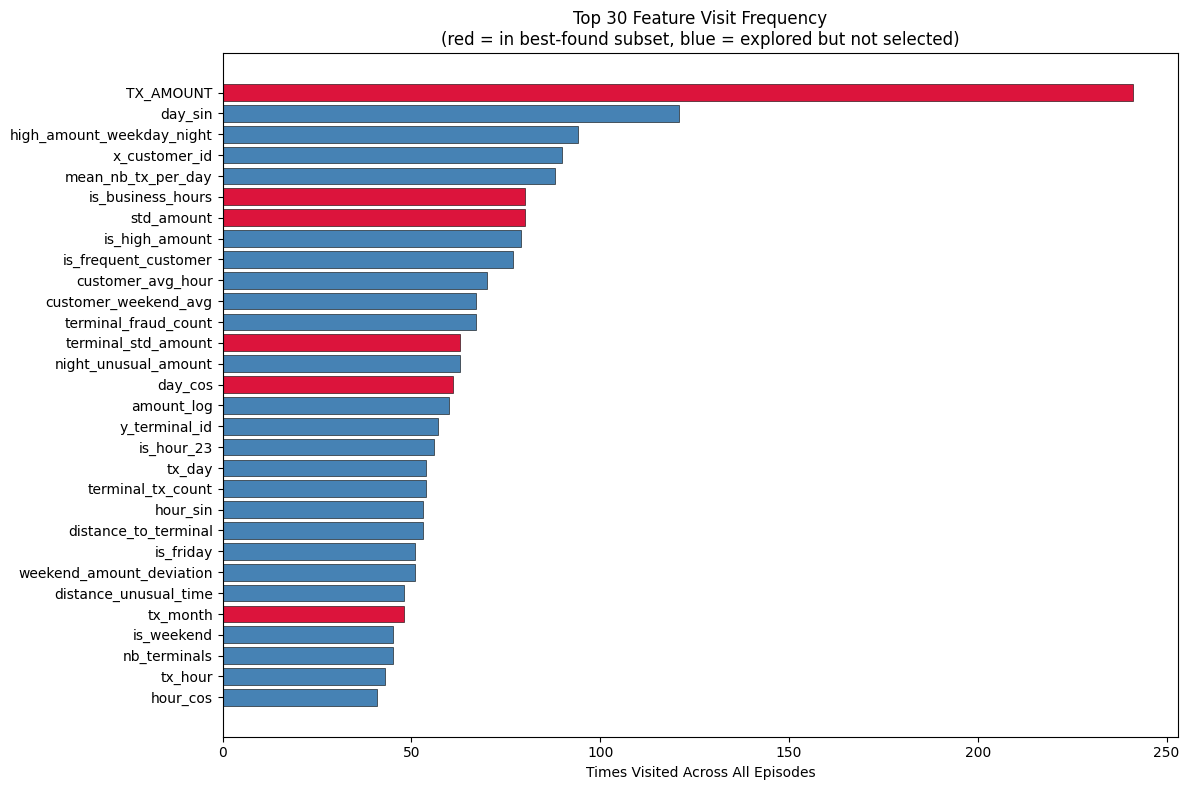

Never-visited features (0): []


In [7]:
# ── 5. Feature Visit Frequency ──────────────────────────────────────────────
visits_sorted  = sorted(feature_visits.items(), key=lambda x: x[1], reverse=True)[:30]
feat_names, visit_counts = zip(*visits_sorted)

plt.figure(figsize=(12, 8))
colors = ['crimson' if f in best_features else 'steelblue' for f in feat_names]
plt.barh(list(feat_names), list(visit_counts),
         color=colors, edgecolor='black', linewidth=0.4)
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Visit Frequency\n(red = in best-found subset, blue = explored but not selected)')
plt.xlabel('Times Visited Across All Episodes')
plt.tight_layout()
plt.show()

# Which features did the agent never explore?
never_visited = [f for f in features if f not in feature_visits]
print(f"Never-visited features ({len(never_visited)}): {never_visited}")

Best RL-selected features (8):
  - TX_AMOUNT
  - day_cos
  - is_business_hours
  - mean_amount
  - std_amount
  - terminal_fraud_rate
  - terminal_std_amount
  - tx_month

ROC-AUC  all 51 features    : 0.8954
ROC-AUC  RL  8 features     : 0.8929
Feature reduction              : 84.3%


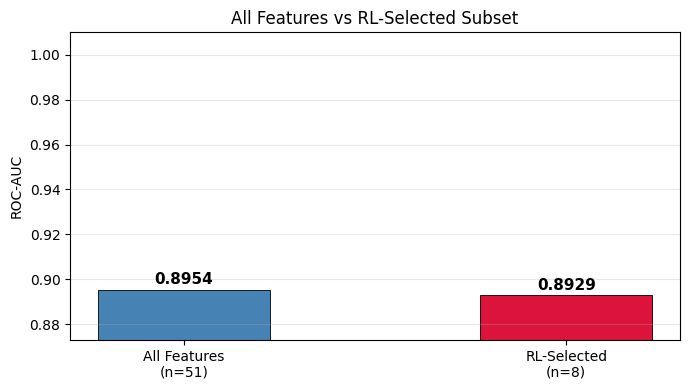

In [8]:
# ── 6. RL-Selected vs All Features Comparison ───────────────────────────────
print(f"Best RL-selected features ({len(best_features)}):")
for f in sorted(best_features):
    print(f"  - {f}")

auc_all = evaluate_subset(features)
auc_rl  = evaluate_subset(best_features)

print(f"\nROC-AUC  all {len(features)} features    : {auc_all:.4f}")
print(f"ROC-AUC  RL  {len(best_features)} features     : {auc_rl:.4f}")
print(f"Feature reduction              : {(1 - len(best_features)/len(features))*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [f'All Features\n(n={len(features)})', f'RL-Selected\n(n={len(best_features)})'],
    [auc_all, auc_rl],
    color=['steelblue', 'crimson'], edgecolor='black', linewidth=0.6, width=0.45
)
for bar, val in zip(bars, [auc_all, auc_rl]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(max(0.5, min(auc_all, auc_rl) - 0.02), 1.01)
ax.set_ylabel('ROC-AUC')
ax.set_title('All Features vs RL-Selected Subset')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

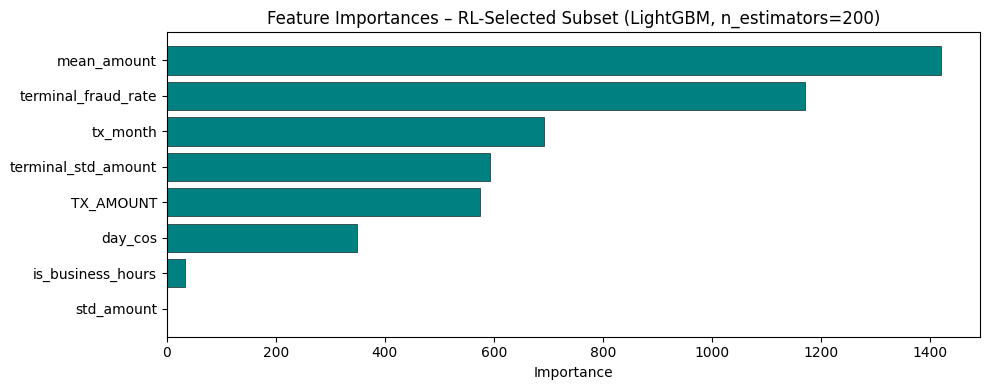

In [9]:
# ── 7. Feature Importances of RL-Selected Subset ────────────────────────────
final_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5, num_leaves=31,
    class_weight='balanced', random_state=42, verbosity=-1
)
final_model.fit(X_train[best_features], y_train)

imp_df = pd.DataFrame({
    'feature':    best_features,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, max(4, len(best_features) * 0.4)))
plt.barh(imp_df['feature'], imp_df['importance'],
         color='teal', edgecolor='black', linewidth=0.4)
plt.title('Feature Importances – RL-Selected Subset (LightGBM, n_estimators=200)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()